In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!git clone -b member3-efficientnet https://github.com/AdityaMishra26/HTR-CNN-Comparative-Analysis.git

Cloning into 'HTR-CNN-Comparative-Analysis'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 35 (delta 7), reused 30 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 764.30 KiB | 24.65 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [3]:
%cd /content/HTR-CNN-Comparative-Analysis

/content/HTR-CNN-Comparative-Analysis


In [4]:
!git branch

* member3-efficientnet


In [5]:
!ls -la


total 24
drwxr-xr-x 3 root root 4096 Aug 29 12:53 .
drwxr-xr-x 1 root root 4096 Aug 29 12:53 ..
drwxr-xr-x 8 root root 4096 Aug 29 12:53 .git
-rw-r--r-- 1 root root 4628 Aug 29 12:53 .gitignore
-rw-r--r-- 1 root root   30 Aug 29 12:53 README.md


In [6]:
!pip install -q opencv-python pillow numpy pandas jiwer datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 50.3 MB/s eta 0:00:00


In [7]:
import torch
import torchvision
import cv2
import PIL
import numpy
import pandas
import jiwer

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("OpenCV:", cv2.__version__)
print("All required libraries loaded successfully!")

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
OpenCV: 4.14.0
All required libraries loaded successfully!


In [8]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.9 MB/s eta 0:00:00


In [9]:
!kaggle --version

Kaggle CLI 2.2.4


In [10]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle token loaded successfully!")

Kaggle token loaded successfully!


In [11]:
!kaggle datasets list -s "iam handwriting word database"

ref                                                     title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------  ----------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nibinv23/iam-handwriting-word-database                  iam_handwriting_word_database             1184020415  2021-05-18 11:29:08.380000          15502         53  0.5              
prathmeshzade/hindi-ocr-synthetic-line-image-text-pair  Hindi OCR synthetic line image-text pair   770451705  2024-03-09 17:16:04.690000            609          7  1                
premabcd/stroke-points-of-special-characters            Stroke Points of Special Characters            59331  2021-07-14 18:36:45.893000             87          1  0.8235294        


In [12]:
!mkdir -p /content/dataset
!kaggle datasets download nibinv23/iam-handwriting-word-database \
    -p /content/dataset \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/nibinv23/iam-handwriting-word-database
License(s): unknown
100% 1.10G/1.10G [00:09<00:00, 127MB/s]



In [13]:
!find /content/dataset -maxdepth 3 -type f | head -50


/content/dataset/words_new.txt
/content/dataset/iam_words/words.txt


In [14]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    level = root.replace("/content/dataset", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        dirs[:] = []

dataset/
  iam_words/
    words/


In [15]:
import os

print(os.listdir("/content/dataset"))

['words_new.txt', 'iam_words']


In [16]:
with open("/content/dataset/words_new.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

print("Total lines:", len(lines))

print("\nFirst 10 lines:\n")
for line in lines[:10]:
    print(line.strip())

Total lines: 44582

First 10 lines:

#--- words.txt ---------------------------------------------------------------#
#
# iam database word information
#
# format: a01-000u-00-00 ok 154 1 408 768 27 51 AT A
#
#     a01-000u-00-00  -> word id for line 00 in form a01-000u
#     ok              -> result of word segmentation
#                            ok: word was correctly
#                            er: segmentation of word can be bad


In [17]:
import os

image_extensions = (".png", ".jpg", ".jpeg")

count = 0

for root, dirs, files in os.walk("/content/dataset/iam_words/words"):
    for file in files:
        if file.lower().endswith(image_extensions):
            count += 1

print("Total image files:", count)

Total image files: 115320


In [18]:
with open("/content/dataset/words_new.txt", "r", encoding="utf-8") as f:
    count = 0

    for line in f:
        line = line.strip()

        if line and not line.startswith("#"):
            print(line)
            count += 1

            if count == 10:
                break

a01-000u-00-00 ok 154 408 768 27 51 AT A
a01-000u-00-01 ok 154 507 766 213 48 NN MOVE
a01-000u-00-02 ok 154 796 764 70 50 TO to
a01-000u-00-03 ok 154 919 757 166 78 VB stop
a01-000u-00-04 ok 154 1185 754 126 61 NPT Mr.
a01-000u-00-05 ok 154 1438 746 382 73 NP Gaitskell
a01-000u-00-06 ok 154 1896 757 173 72 IN from
a01-000u-01-00 ok 156 395 932 441 100 VBG nominating
a01-000u-01-01 ok 156 901 958 147 79 DTI any
a01-000u-01-02 ok 156 1112 958 208 42 AP more


In [19]:
import os

image_files = []

for root, dirs, files in os.walk("/content/dataset/iam_words/words"):
    for file in files:
        if file.lower().endswith(".png"):
            image_files.append(os.path.join(root, file))

print("First 10 image paths:")

for path in image_files[:10]:
    print(path)

First 10 image paths:
/content/dataset/iam_words/words/g03/g03-040/g03-040-00-00.png
/content/dataset/iam_words/words/g03/g03-040/g03-040-00-06.png
/content/dataset/iam_words/words/g03/g03-040/g03-040-06-02.png
/content/dataset/iam_words/words/g03/g03-040/g03-040-02-03.png
/content/dataset/iam_words/words/g03/g03-040/g03-040-00-05.png
/content/dataset/iam_words/words/g03/g03-040/g03-040-01-04.png
/content/dataset/iam_words/words/g03/g03-040/g03-040-01-06.png
/content/dataset/iam_words/words/g03/g03-040/g03-040-02-07.png
/content/dataset/iam_words/words/g03/g03-040/g03-040-03-00.png
/content/dataset/iam_words/words/g03/g03-040/g03-040-05-06.png


In [20]:
import os
import pandas as pd

# Location of the metadata file
metadata_file = "/content/dataset/words_new.txt"

# Location of handwritten images
image_folder = "/content/dataset/iam_words/words"

# ---------------------------------------------------
# 1. Read metadata and create ID → label dictionary
# ---------------------------------------------------

labels = {}

with open(metadata_file, "r", encoding="utf-8") as f:

    for line in f:
        line = line.strip()

        # Ignore comments and empty lines
        if not line or line.startswith("#"):
            continue

        parts = line.split()

        # We need at least 9 columns
        if len(parts) >= 9:

            word_id = parts[0]
            status = parts[1]
            label = parts[-1]

            # Only use correctly segmented words
            if status == "ok":
                labels[word_id] = label

print("Number of labels:", len(labels))


# ---------------------------------------------------
# 2. Find all PNG images
# ---------------------------------------------------

data = []

for root, dirs, files in os.walk(image_folder):

    for file in files:

        if file.lower().endswith(".png"):

            # Remove .png to get image ID
            word_id = os.path.splitext(file)[0]

            # Check if corresponding label exists
            if word_id in labels:

                image_path = os.path.join(root, file)

                data.append({
                    "image_path": image_path,
                    "word_id": word_id,
                    "label": labels[word_id]
                })


# ---------------------------------------------------
# 3. Create DataFrame
# ---------------------------------------------------

df = pd.DataFrame(data)

print("Total matched images:", len(df))

print("\nFirst 10 records:")
print(df.head(10))

Number of labels: 38305
Total matched images: 38305

First 10 records:
                                          image_path        word_id     label
0  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-03-04  prepared
1  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-01-09    paying
2  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-02-06      lace
3  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-04-03         ,
4  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-00-00        We
5  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-02-04       for
6  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-00-02      from
7  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-01-02       was
8  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-02-09       But
9  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-04-00       for


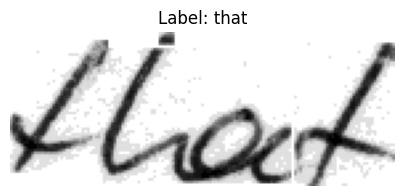

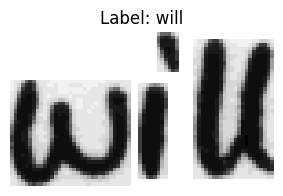

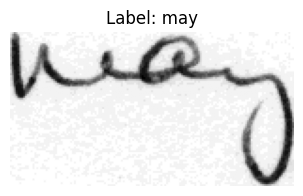

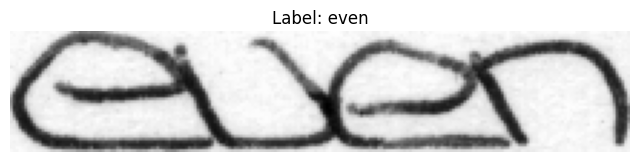

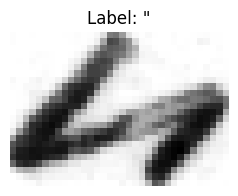

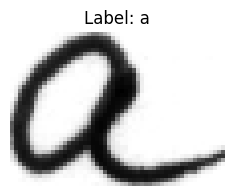

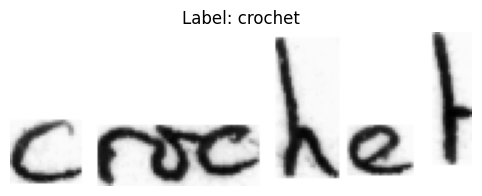

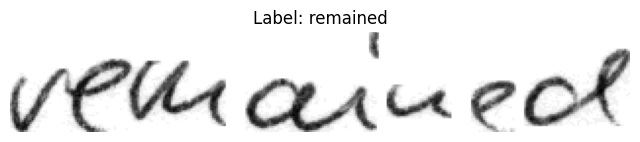

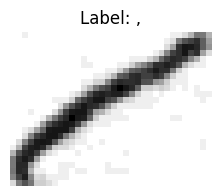

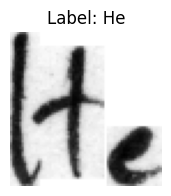

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

# Select 10 random samples
samples = df.sample(10, random_state=42)

for _, row in samples.iterrows():
    image = Image.open(row["image_path"])

    plt.figure(figsize=(8, 2))
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {row['label']}")
    plt.axis("off")
    plt.show()

In [22]:
# Collect all unique characters from all labels

all_text = "".join(df["label"].astype(str).tolist())

characters = sorted(set(all_text))

print("Number of unique characters:", len(characters))
print("\nCharacters:")
print(characters)

Number of unique characters: 76

Characters:
['!', '"', '#', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [23]:
word_lengths = df["label"].astype(str).str.len()

print("Shortest word length:", word_lengths.min())
print("Longest word length:", word_lengths.max())
print("Average word length:", word_lengths.mean())

Shortest word length: 1
Longest word length: 19
Average word length: 4.30241482835139


In [24]:
all_text = "".join(df["label"].astype(str).tolist())
characters = sorted(set(all_text))

print("Number of unique characters:", len(characters))
print("\nCharacters:")
print(characters)

Number of unique characters: 76

Characters:
['!', '"', '#', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [25]:
word_lengths = df["label"].astype(str).str.len()

print("Shortest word length:", word_lengths.min())
print("Longest word length:", word_lengths.max())
print("Average word length:", word_lengths.mean())

Shortest word length: 1
Longest word length: 19
Average word length: 4.30241482835139


In [26]:
# Create character-to-index mapping for CTC

characters = sorted(set("".join(df["label"].astype(str))))

# Index 0 is reserved for the CTC blank token
char_to_idx = {char: idx + 1 for idx, char in enumerate(characters)}

# Reverse mapping: number → character
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

print("Number of characters:", len(characters))
print("\nCharacter to index:")
print(char_to_idx)

Number of characters: 76

Character to index:
{'!': 1, '"': 2, '#': 3, "'": 4, '(': 5, ')': 6, '*': 7, ',': 8, '-': 9, '.': 10, '/': 11, '0': 12, '1': 13, '2': 14, '3': 15, '4': 16, '5': 17, '6': 18, '7': 19, '8': 20, '9': 21, ':': 22, ';': 23, '?': 24, 'A': 25, 'B': 26, 'C': 27, 'D': 28, 'E': 29, 'F': 30, 'G': 31, 'H': 32, 'I': 33, 'J': 34, 'K': 35, 'L': 36, 'M': 37, 'N': 38, 'O': 39, 'P': 40, 'Q': 41, 'R': 42, 'S': 43, 'T': 44, 'U': 45, 'V': 46, 'W': 47, 'X': 48, 'Y': 49, 'Z': 50, 'a': 51, 'b': 52, 'c': 53, 'd': 54, 'e': 55, 'f': 56, 'g': 57, 'h': 58, 'i': 59, 'j': 60, 'k': 61, 'l': 62, 'm': 63, 'n': 64, 'o': 65, 'p': 66, 'q': 67, 'r': 68, 's': 69, 't': 70, 'u': 71, 'v': 72, 'w': 73, 'x': 74, 'y': 75, 'z': 76}


In [27]:
test_word = df.iloc[0]["label"]

print("Original word:", test_word)

encoded = [char_to_idx[char] for char in test_word]

print("Encoded:", encoded)

decoded = "".join(idx_to_char[i] for i in encoded)

print("Decoded:", decoded)

Original word: prepared
Encoded: [66, 68, 55, 66, 51, 68, 55, 54]
Decoded: prepared


In [28]:
import json
import os

vocab_path = "/content/character_vocab.json"

with open(vocab_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "char_to_idx": char_to_idx,
            "idx_to_char": {str(k): v for k, v in idx_to_char.items()},
            "blank_index": 0
        },
        f,
        ensure_ascii=False,
        indent=2
    )

print("Vocabulary saved to:", vocab_path)

Vocabulary saved to: /content/character_vocab.json


In [29]:
# Look at some word IDs

print(df["word_id"].head(20).tolist())

['e01-014-03-04', 'e01-014-01-09', 'e01-014-02-06', 'e01-014-04-03', 'e01-014-00-00', 'e01-014-02-04', 'e01-014-00-02', 'e01-014-01-02', 'e01-014-02-09', 'e01-014-04-00', 'e01-014-02-02', 'e01-014-05-03', 'e01-014-01-06', 'e01-014-04-09', 'e01-014-00-06', 'e01-014-03-07', 'e01-014-04-04', 'e01-014-06-04', 'e01-014-04-05', 'e01-014-02-00']


In [30]:
# Check how many different prefixes exist

prefixes = df["word_id"].str.split("-").str[0]

print("Number of unique prefixes:", prefixes.nunique())
print("First 20 prefixes:", prefixes.unique()[:20])

Number of unique prefixes: 28
First 20 prefixes: ['e01' 'b03' 'a02' 'a01' 'b04' 'd04' 'd03' 'a05' 'a04' 'd06' 'c01' 'c03'
 'c02' 'c04' 'c06' 'b01' 'b02' 'e02' 'd07' 'b05']


In [31]:
# Extract the form ID from each word ID

df["form_id"] = df["word_id"].str.rsplit("-", n=2).str[0]

print("First 10 word IDs:")
print(df["word_id"].head(10).tolist())

print("\nCorresponding form IDs:")
print(df["form_id"].head(10).tolist())

print("\nNumber of unique forms:")
print(df["form_id"].nunique())

First 10 word IDs:
['e01-014-03-04', 'e01-014-01-09', 'e01-014-02-06', 'e01-014-04-03', 'e01-014-00-00', 'e01-014-02-04', 'e01-014-00-02', 'e01-014-01-02', 'e01-014-02-09', 'e01-014-04-00']

Corresponding form IDs:
['e01-014', 'e01-014', 'e01-014', 'e01-014', 'e01-014', 'e01-014', 'e01-014', 'e01-014', 'e01-014', 'e01-014']

Number of unique forms:
610


In [32]:
form_counts = df["form_id"].value_counts()

print("Total unique forms:", len(form_counts))

print("\nFirst 20 forms and their word counts:")
print(form_counts.head(20))

Total unique forms: 610

First 20 forms and their word counts:
form_id
b05-074     105
e02-086     103
b05-032      98
d06-086      97
b01-057      95
b02-045      94
b01-038      92
b06-075      90
b01-079      90
e07-061      90
c03-021d     89
a04-019      89
a04-092      89
a02-027      89
d01-019      89
e01-032      89
a02-072      88
a03-063      88
a01-117u     87
a03-047      86
Name: count, dtype: int64


In [33]:
print("\nMinimum words in a form:", form_counts.min())
print("Maximum words in a form:", form_counts.max())
print("Average words per form:", form_counts.mean())


Minimum words in a form: 6
Maximum words in a form: 105
Average words per form: 62.795081967213115


In [34]:
# Extract writer ID from each word ID

df["writer_id"] = df["word_id"].str.split("-").str[0]

print("First 20 writer IDs:")
print(df["writer_id"].head(20).tolist())

print("\nNumber of unique writers in our dataset:")
print(df["writer_id"].nunique())

First 20 writer IDs:
['e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01', 'e01']

Number of unique writers in our dataset:
28


In [35]:
# Count how many word images belong to each writer

writer_counts = df["writer_id"].value_counts()

print("Word images per writer:")
print(writer_counts)

Word images per writer:
writer_id
a01    4189
c03    3928
b04    1981
d06    1875
b06    1819
a04    1818
a02    1799
a05    1713
a06    1712
c04    1703
b01    1656
e04    1553
a03    1449
d04    1431
c06    1397
e01    1209
b05    1058
c02     957
e06     953
d01     892
e02     704
b03     487
d07     468
e07     467
b02     401
d05     350
c01     201
d03     135
Name: count, dtype: int64


In [36]:
from sklearn.model_selection import train_test_split

# Get unique writers
writers = df["writer_id"].unique()

print("Total writers:", len(writers))

# 80% writers -> train
# 20% writers -> temporary set
train_writers, temp_writers = train_test_split(
    writers,
    test_size=0.20,
    random_state=42
)

# Split remaining 20% into validation and test
val_writers, test_writers = train_test_split(
    temp_writers,
    test_size=0.50,
    random_state=42
)

print("Training writers:", len(train_writers))
print("Validation writers:", len(val_writers))
print("Test writers:", len(test_writers))

Total writers: 28
Training writers: 22
Validation writers: 3
Test writers: 3


In [37]:
df["writer_id"]

,writer_id
0,e01
1,e01
2,e01
3,e01
4,e01
...,...
38300,d05
38301,d05
38302,d05
38303,d05


In [38]:
import os
import pandas as pd

metadata_file = "/content/dataset/words_new.txt"
image_folder = "/content/dataset/iam_words/words"

labels = {}

with open(metadata_file, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if not line or line.startswith("#"):
            continue

        parts = line.split()

        if len(parts) >= 9:
            word_id = parts[0]
            status = parts[1]
            label = parts[-1]

            if status == "ok":
                labels[word_id] = label

data = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.lower().endswith(".png"):

            word_id = os.path.splitext(file)[0]

            if word_id in labels:
                data.append({
                    "image_path": os.path.join(root, file),
                    "word_id": word_id,
                    "label": labels[word_id]
                })

df = pd.DataFrame(data)

print("Total matched images:", len(df))
print(df.head())

Total matched images: 38305
                                          image_path        word_id     label
0  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-03-04  prepared
1  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-01-09    paying
2  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-02-06      lace
3  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-04-03         ,
4  /content/dataset/iam_words/words/e01/e01-014/e...  e01-014-00-00        We


In [39]:
import os

print(os.path.exists("/content/dataset"))
print(os.listdir("/content")[:20])

True
['.config', 'dataset', 'character_vocab.json', 'HTR-CNN-Comparative-Analysis', 'sample_data']


In [40]:
!pip install -q -U kaggle

In [41]:
!mkdir -p /content/dataset

!kaggle datasets download nibinv23/iam-handwriting-word-database \
    -p /content/dataset \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/nibinv23/iam-handwriting-word-database
License(s): unknown
100% 1.10G/1.10G [00:12<00:00, 91.4MB/s]



In [42]:
import os

print(os.listdir("/content/dataset"))

['words_new.txt', 'iam_words']


In [43]:
print(os.path.exists("/content/dataset/words_new.txt"))
print(os.path.exists("/content/dataset/iam_words/words"))

True
True


In [44]:
import os
import pandas as pd

metadata_file = "/content/dataset/words_new.txt"
image_folder = "/content/dataset/iam_words/words"

labels = {}

with open(metadata_file, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if not line or line.startswith("#"):
            continue

        parts = line.split()

        if len(parts) >= 9:
            word_id = parts[0]
            status = parts[1]
            label = parts[-1]

            if status == "ok":
                labels[word_id] = label

data = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.lower().endswith(".png"):
            word_id = os.path.splitext(file)[0]

            if word_id in labels:
                data.append({
                    "image_path": os.path.join(root, file),
                    "word_id": word_id,
                    "label": labels[word_id]
                })

df = pd.DataFrame(data)

print("Total matched images:", len(df))

Total matched images: 38305


In [45]:
# Create writer ID from the word ID

df["writer_id"] = df["word_id"].str.split("-").str[0]

print("Number of unique writers:", df["writer_id"].nunique())

print("\nWriter-wise image counts:")
print(df["writer_id"].value_counts())

Number of unique writers: 28

Writer-wise image counts:
writer_id
a01    4189
c03    3928
b04    1981
d06    1875
b06    1819
a04    1818
a02    1799
a05    1713
a06    1712
c04    1703
b01    1656
e04    1553
a03    1449
d04    1431
c06    1397
e01    1209
b05    1058
c02     957
e06     953
d01     892
e02     704
b03     487
d07     468
e07     467
b02     401
d05     350
c01     201
d03     135
Name: count, dtype: int64


In [46]:
from sklearn.model_selection import train_test_split

# Get unique writer IDs
writers = df["writer_id"].unique()

# 80% writers for training
# 20% temporarily held out
train_writers, temp_writers = train_test_split(
    writers,
    test_size=0.20,
    random_state=42
)

# Split remaining 20% equally:
# 10% validation + 10% test
val_writers, test_writers = train_test_split(
    temp_writers,
    test_size=0.50,
    random_state=42
)

print("Total writers:", len(writers))
print("Training writers:", len(train_writers))
print("Validation writers:", len(val_writers))
print("Test writers:", len(test_writers))

Total writers: 28
Training writers: 22
Validation writers: 3
Test writers: 3


In [47]:
train_df = df[df["writer_id"].isin(train_writers)].copy()
val_df = df[df["writer_id"].isin(val_writers)].copy()
test_df = df[df["writer_id"].isin(test_writers)].copy()

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Training images: 29674
Validation images: 3980
Test images: 4651

Total: 38305


In [48]:
train_set = set(train_df["writer_id"])
val_set = set(val_df["writer_id"])
test_set = set(test_df["writer_id"])

print("Train ∩ Validation:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Validation ∩ Test:", len(val_set & test_set))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [49]:
train_df.to_csv("/content/train_split.csv", index=False)
val_df.to_csv("/content/val_split.csv", index=False)
test_df.to_csv("/content/test_split.csv", index=False)

print("Train/validation/test split saved successfully!")

Train/validation/test split saved successfully!


Original image size: (200, 78)
Label: agreement


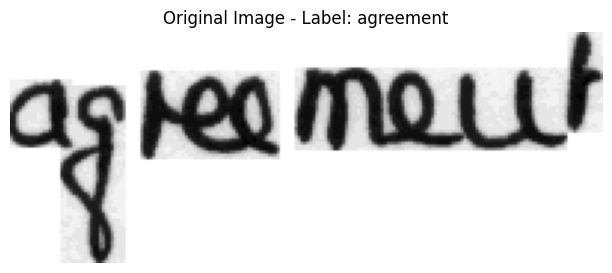

In [50]:
from PIL import Image
import matplotlib.pyplot as plt

# Take one sample
sample = train_df.iloc[0]

image_path = sample["image_path"]
label = sample["label"]

# Open image
image = Image.open(image_path).convert("L")

print("Original image size:", image.size)
print("Label:", label)

plt.figure(figsize=(8, 3))
plt.imshow(image, cmap="gray")
plt.title(f"Original Image - Label: {label}")
plt.axis("off")
plt.show()

In [51]:
from PIL import ImageOps

TARGET_HEIGHT = 64
TARGET_WIDTH = 256

def preprocess_image(image):
    # Convert to grayscale
    image = image.convert("L")

    # Calculate new width while preserving aspect ratio
    original_width, original_height = image.size

    new_width = int(
        original_width * TARGET_HEIGHT / original_height
    )

    # Limit width to target width
    new_width = min(new_width, TARGET_WIDTH)

    # Resize
    image = image.resize(
        (new_width, TARGET_HEIGHT),
        Image.Resampling.LANCZOS
    )

    # Create white canvas
    canvas = Image.new(
        "L",
        (TARGET_WIDTH, TARGET_HEIGHT),
        color=255
    )

    # Put resized image on canvas
    canvas.paste(image, (0, 0))

    return canvas

Processed image size: (256, 64)


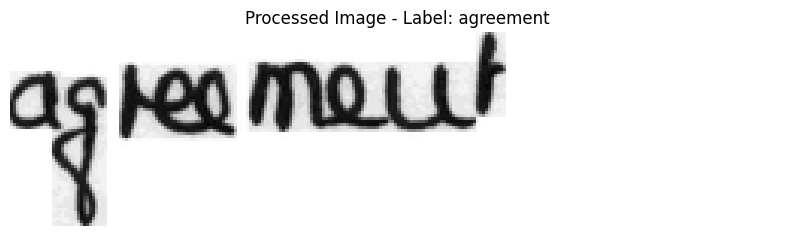

In [52]:
processed = preprocess_image(Image.open(image_path))

print("Processed image size:", processed.size)

plt.figure(figsize=(10, 3))
plt.imshow(processed, cmap="gray")
plt.title(f"Processed Image - Label: {label}")
plt.axis("off")
plt.show()

In [53]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cu128


In [54]:
import torchvision.transforms as transforms

image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("Image transformation created!")

Image transformation created!


In [55]:
class HTRDataset(Dataset):

    def __init__(self, dataframe, char_to_idx, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.char_to_idx = char_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        # Get image path and label
        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        label = str(row["label"])

        # Open image
        image = Image.open(image_path).convert("L")

        # Apply our resize + padding preprocessing
        image = preprocess_image(image)

        # Convert grayscale → RGB (3 channels)
        image = image.convert("RGB")

        # Convert image to tensor
        if self.transform:
            image = self.transform(image)

        # Convert characters to integer IDs
        label_encoded = [
            self.char_to_idx[char]
            for char in label
        ]

        label_encoded = torch.tensor(
            label_encoded,
            dtype=torch.long
        )

        return image, label_encoded, label

In [56]:
# Recreate character vocabulary and CTC mapping

all_text = "".join(df["label"].astype(str).tolist())

characters = sorted(set(all_text))

# 0 is reserved for CTC blank
char_to_idx = {
    char: idx + 1
    for idx, char in enumerate(characters)
}

idx_to_char = {
    idx: char
    for char, idx in char_to_idx.items()
}

print("Number of characters:", len(characters))
print("CTC blank index: 0")
print("Vocabulary recreated successfully!")

Number of characters: 76
CTC blank index: 0
Vocabulary recreated successfully!


In [57]:
train_dataset = HTRDataset(
    train_df,
    char_to_idx,
    transform=image_transform
)

val_dataset = HTRDataset(
    val_df,
    char_to_idx,
    transform=image_transform
)

test_dataset = HTRDataset(
    test_df,
    char_to_idx,
    transform=image_transform
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 29674
Validation samples: 3980
Test samples: 4651


In [58]:
image, encoded_label, original_label = train_dataset[0]

print("Image shape:", image.shape)
print("Encoded label:", encoded_label.tolist())
print("Original label:", original_label)

Image shape: torch.Size([3, 64, 256])
Encoded label: [51, 57, 68, 55, 55, 63, 55, 64, 70]
Original label: agreement


In [59]:
def ctc_collate_fn(batch):

    images = []
    labels = []
    label_lengths = []
    original_labels = []

    for image, label, original_label in batch:

        images.append(image)
        labels.append(label)
        label_lengths.append(len(label))
        original_labels.append(original_label)

    # Stack images into one tensor
    images = torch.stack(images)

    # Combine all labels into one long tensor
    labels = torch.cat(labels)

    # Convert lengths to tensor
    label_lengths = torch.tensor(
        label_lengths,
        dtype=torch.long
    )

    return images, labels, label_lengths, original_labels


print("CTC collate function created!")

CTC collate function created!


In [60]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=ctc_collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=ctc_collate_fn,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=ctc_collate_fn,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created!")

DataLoaders created!


In [61]:
images, labels, label_lengths, original_labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Label lengths:", label_lengths[:10].tolist())
print("First original labels:", original_labels[:10])

Images shape: torch.Size([32, 3, 64, 256])
Labels shape: torch.Size([140])
Label lengths: [3, 3, 4, 8, 8, 3, 9, 5, 2, 7]
First original labels: ['the', 'his', 'cent', 'believed', 'maintain', 'and', 'developed', 'codex', 'us', 'service']


In [62]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

print("Loading EfficientNet-B0...")

Loading EfficientNet-B0...


In [63]:
weights = EfficientNet_B0_Weights.DEFAULT

cnn = efficientnet_b0(weights=weights)

print(cnn)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 126MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [64]:
cnn.classifier = nn.Identity()

print(cnn)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn = cnn.to(device)
cnn.eval()

images, labels, label_lengths, original_labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    features = cnn(images)

print("Input shape:", images.shape)
print("CNN output shape:", features.shape)

Input shape: torch.Size([32, 3, 64, 256])
CNN output shape: torch.Size([32, 1280])


In [66]:
# Keep only EfficientNet's convolutional feature extractor
cnn_features = cnn.features

cnn_features = cnn_features.to(device)

print(cnn_features)

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (activation): SiLU(inplace=True)
          (scale_activation): Sigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), 

In [67]:
cnn_features.eval()

with torch.no_grad():
    feature_maps = cnn_features(images)

print("Input shape:", images.shape)
print("Feature map shape:", feature_maps.shape)

Input shape: torch.Size([32, 3, 64, 256])
Feature map shape: torch.Size([32, 1280, 2, 8])


In [68]:
# feature_maps shape:
# [batch, channels, height, width]
# [32, 1280, 2, 8]

batch_size, channels, height, width = feature_maps.shape

# Move width to the sequence dimension
sequence = feature_maps.permute(0, 3, 1, 2)

# Combine channels and height
sequence = sequence.reshape(
    batch_size,
    width,
    channels * height
)

print("Original feature map shape:", feature_maps.shape)
print("Sequence shape:", sequence.shape)

Original feature map shape: torch.Size([32, 1280, 2, 8])
Sequence shape: torch.Size([32, 8, 2560])


In [69]:
bilstm = nn.LSTM(
    input_size=2560,
    hidden_size=256,
    num_layers=2,
    batch_first=True,
    bidirectional=True,
    dropout=0.3
)

bilstm = bilstm.to(device)

print(bilstm)

LSTM(2560, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)


In [70]:
bilstm.eval()

with torch.no_grad():
    lstm_output, _ = bilstm(sequence)

print("Input to BiLSTM:", sequence.shape)
print("BiLSTM output:", lstm_output.shape)

Input to BiLSTM: torch.Size([32, 8, 2560])
BiLSTM output: torch.Size([32, 8, 512])


In [71]:
num_classes = len(char_to_idx) + 1

print("Number of characters:", len(char_to_idx))
print("CTC classes:", num_classes)
print("Blank index:", 0)

Number of characters: 76
CTC classes: 77
Blank index: 0


In [72]:
ctc_classifier = nn.Linear(
    512,
    num_classes
)

ctc_classifier = ctc_classifier.to(device)

print(ctc_classifier)

Linear(in_features=512, out_features=77, bias=True)


In [73]:
ctc_classifier.eval()

with torch.no_grad():
    logits = ctc_classifier(lstm_output)

print("BiLSTM output:", lstm_output.shape)
print("CTC logits:", logits.shape)

BiLSTM output: torch.Size([32, 8, 512])
CTC logits: torch.Size([32, 8, 77])


In [74]:
logits_ctc = logits.permute(1, 0, 2)

print("CTC input shape:", logits_ctc.shape)

CTC input shape: torch.Size([8, 32, 77])


In [75]:
x = images

print("Input:", x.shape)

for i, layer in enumerate(cnn.features):
    x = layer(x)
    print(f"Stage {i}: {x.shape}")

Input: torch.Size([32, 3, 64, 256])
Stage 0: torch.Size([32, 32, 32, 128])
Stage 1: torch.Size([32, 16, 32, 128])
Stage 2: torch.Size([32, 24, 16, 64])
Stage 3: torch.Size([32, 40, 8, 32])
Stage 4: torch.Size([32, 80, 4, 16])
Stage 5: torch.Size([32, 112, 4, 16])
Stage 6: torch.Size([32, 192, 2, 8])
Stage 7: torch.Size([32, 320, 2, 8])
Stage 8: torch.Size([32, 1280, 2, 8])


In [76]:
# Use EfficientNet stages 0 to 3
cnn_sequence_features = nn.Sequential(
    *list(cnn.features.children())[:4]
).to(device)

cnn_sequence_features.eval()

with torch.no_grad():
    feature_maps = cnn_sequence_features(images)

print("Feature map shape:", feature_maps.shape)

Feature map shape: torch.Size([32, 40, 8, 32])


In [77]:
batch_size, channels, height, width = feature_maps.shape

sequence = feature_maps.permute(0, 3, 1, 2)

sequence = sequence.reshape(
    batch_size,
    width,
    channels * height
)

print("Sequence shape:", sequence.shape)

Sequence shape: torch.Size([32, 32, 320])


In [78]:
bilstm = nn.LSTM(
    input_size=320,
    hidden_size=256,
    num_layers=2,
    batch_first=True,
    bidirectional=True,
    dropout=0.3
).to(device)

bilstm.eval()

with torch.no_grad():
    lstm_output, _ = bilstm(sequence)

print("BiLSTM output shape:", lstm_output.shape)

BiLSTM output shape: torch.Size([32, 32, 512])


In [79]:
num_classes = len(char_to_idx) + 1

ctc_classifier = nn.Linear(
    512,
    num_classes
).to(device)

ctc_classifier.eval()

with torch.no_grad():
    logits = ctc_classifier(lstm_output)

print("Logits shape:", logits.shape)

Logits shape: torch.Size([32, 32, 77])


In [80]:
logits_ctc = logits.permute(1, 0, 2)

print("CTC input shape:", logits_ctc.shape)

CTC input shape: torch.Size([32, 32, 77])


In [81]:
ctc_loss = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

print("CTC Loss created successfully!")

CTC Loss created successfully!


In [82]:
input_lengths = torch.full(
    size=(images.size(0),),
    fill_value=logits_ctc.size(0),
    dtype=torch.long
).to(device)

label_lengths = label_lengths.to(device)
labels = labels.to(device)

print("Input lengths:", input_lengths[:10])
print("Label lengths:", label_lengths[:10])

Input lengths: tensor([32, 32, 32, 32, 32, 32, 32, 32, 32, 32], device='cuda:0')
Label lengths: tensor([3, 2, 4, 6, 3, 3, 5, 6, 1, 4], device='cuda:0')


In [83]:
log_probs = logits_ctc.log_softmax(2)

loss = ctc_loss(
    log_probs,
    labels,
    input_lengths,
    label_lengths
)

print("CTC Loss:", loss.item())

CTC Loss: 42.2667236328125


In [84]:
print("Maximum label length in current batch:",
      label_lengths.max().item())

print("Available CTC time steps:",
      input_lengths[0].item())

Maximum label length in current batch: 11
Available CTC time steps: 32


In [85]:
class EfficientNetBiLSTMCTC(nn.Module):

    def __init__(
        self,
        num_classes,
        hidden_size=256,
        num_layers=2
    ):
        super().__init__()

        # --------------------------------
        # 1. EfficientNet-B0 CNN
        # --------------------------------

        weights = EfficientNet_B0_Weights.DEFAULT

        efficientnet = efficientnet_b0(
            weights=weights
        )

        # Use only stages 0-3
        self.cnn = nn.Sequential(
            *list(efficientnet.features.children())[:4]
        )

        # --------------------------------
        # 2. BiLSTM
        # --------------------------------

        # Stage 3 output:
        # channels = 40
        # height = 8
        # feature size = 40 × 8 = 320

        self.lstm = nn.LSTM(
            input_size=320,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # --------------------------------
        # 3. CTC classifier
        # --------------------------------

        self.classifier = nn.Linear(
            hidden_size * 2,
            num_classes
        )

    def forward(self, x):

        # CNN feature extraction
        x = self.cnn(x)

        # x:
        # [batch, channels, height, width]

        batch_size, channels, height, width = x.size()

        # Width becomes time dimension
        x = x.permute(
            0, 3, 1, 2
        )

        # Combine channels + height
        x = x.reshape(
            batch_size,
            width,
            channels * height
        )

        # BiLSTM
        x, _ = self.lstm(x)

        # Character logits
        x = self.classifier(x)

        # CTC expects:
        # [time, batch, classes]

        x = x.permute(1, 0, 2)

        return x

In [86]:
num_classes = len(char_to_idx) + 1

model = EfficientNetBiLSTMCTC(
    num_classes=num_classes
)

model = model.to(device)

print(model)

EfficientNetBiLSTMCTC(
  (cnn): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormAct

In [87]:
model.eval()

with torch.no_grad():
    output = model(images)

print("Input:", images.shape)
print("Model output:", output.shape)

Input: torch.Size([32, 3, 64, 256])
Model output: torch.Size([32, 32, 77])


In [88]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 2865935
Trainable parameters: 2865935


In [89]:
import torch.optim as optim

# CTC Loss
criterion = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

print("CTC loss and optimizer created!")

CTC loss and optimizer created!


In [90]:
model.train()

# Get one batch
images, labels, label_lengths, original_labels = next(iter(train_loader))

# Move data to GPU
images = images.to(device)
labels = labels.to(device)
label_lengths = label_lengths.to(device)

# Forward pass
logits = model(images)

# Convert logits to log probabilities
log_probs = logits.log_softmax(2)

# Every image currently produces 32 time steps
input_lengths = torch.full(
    size=(images.size(0),),
    fill_value=logits.size(0),
    dtype=torch.long,
    device=device
)

# Calculate CTC loss
loss = criterion(
    log_probs,
    labels,
    input_lengths,
    label_lengths
)

print("Loss before backward:", loss.item())

# Backpropagation
optimizer.zero_grad()
loss.backward()

# Update model weights
optimizer.step()

print("One training step completed!")

Loss before backward: 41.66011047363281
One training step completed!


In [91]:
print("Training step successful.")
print("Current loss:", loss.item())

Training step successful.
Current loss: 41.66011047363281


In [92]:
def ctc_greedy_decode(logits, idx_to_char, blank_index=0):
    """
    Greedy CTC decoder.

    logits shape:
        [time, batch, classes]
    """

    # Get most likely class at each timestep
    predictions = logits.argmax(dim=2)

    decoded_words = []

    # Process each item in the batch
    for batch_prediction in predictions.transpose(0, 1):

        word = []
        previous = blank_index

        for index in batch_prediction.tolist():

            # Ignore blank
            if index == blank_index:
                previous = index
                continue

            # Remove consecutive repeated characters
            if index == previous:
                continue

            # Convert index → character
            if index in idx_to_char:
                word.append(idx_to_char[index])

            previous = index

        decoded_words.append("".join(word))

    return decoded_words


print("CTC decoder created!")

CTC decoder created!


In [93]:
model.eval()

with torch.no_grad():
    logits = model(images)

decoded_words = ctc_greedy_decode(
    logits,
    idx_to_char,
    blank_index=0
)

print("Predicted words:")
for i in range(10):
    print(
        f"Actual: {original_labels[i]:15s} | "
        f"Predicted: {decoded_words[i]}"
    )

Predicted words:
Actual: it              | Predicted: 0Gw?lNwnI
Actual: four            | Predicted: 5Dw05;C1wNXw/nI
Actual: that            | Predicted: rV;cr;ND0D;D;NwNwX/;nI
Actual: .               | Predicted: NcNrNwiI
Actual: in              | Predicted: r;1q1CNDXNXw7;FI
Actual: not             | Predicted: 0Gw0IwNwinI
Actual: Sir             | Predicted: ;b;51UwN7w/nI
Actual: they            | Predicted: H(*U0U0/0N7/ni
Actual: bitterest       | Predicted: CzrCcr*0v0Cdc0c0f
Actual: the             | Predicted: ;5w*5,;irDrXnI


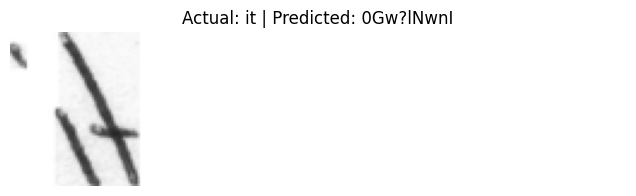

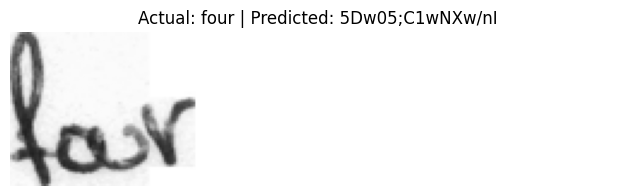

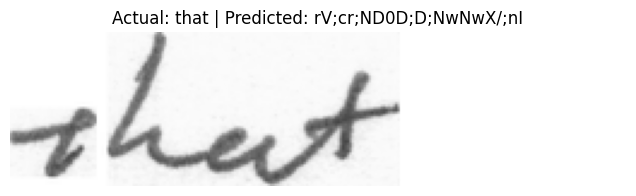

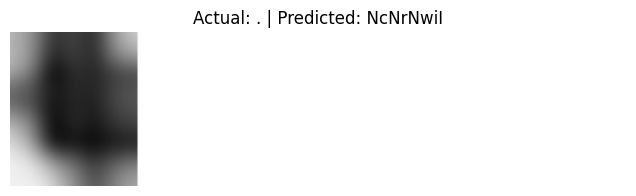

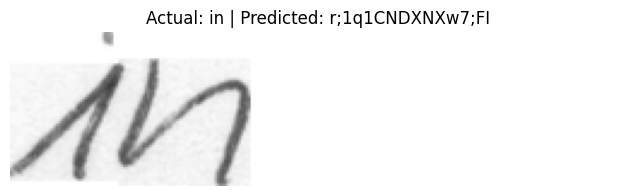

In [94]:
import matplotlib.pyplot as plt

for i in range(5):

    image_tensor = images[i].cpu()

    # Convert CHW → HWC
    image_display = image_tensor.permute(1, 2, 0)

    # Undo normalization approximately
    image_display = image_display * 0.5 + 0.5

    plt.figure(figsize=(8, 2))
    plt.imshow(image_display, cmap="gray")

    plt.title(
        f"Actual: {original_labels[i]} | "
        f"Predicted: {decoded_words[i]}"
    )

    plt.axis("off")
    plt.show()

In [95]:
!pip install -q jiwer

In [96]:
from jiwer import wer, cer

print("jiwer imported successfully!")

jiwer imported successfully!


In [97]:
actual = "paint"
predicted = "pant"

print("CER:", cer(actual, predicted))
print("WER:", wer(actual, predicted))

CER: 0.2
WER: 1.0


In [98]:
actual_words = [
    str(word)
    for word in original_labels
]

predicted_words = [
    str(word)
    for word in decoded_words
]

current_cer = cer(
    actual_words,
    predicted_words
)

current_wer = wer(
    actual_words,
    predicted_words
)

print("Current CER:", current_cer)
print("Current WER:", current_wer)

Current CER: 3.593984962406015
Current WER: 1.0


In [99]:
def evaluate_model(model, data_loader, criterion, device):

    model.eval()

    total_loss = 0.0
    all_actual = []
    all_predicted = []

    with torch.no_grad():

        for images, labels, label_lengths, original_labels in data_loader:

            # Move tensors to GPU/CPU
            images = images.to(device)
            labels = labels.to(device)
            label_lengths = label_lengths.to(device)

            # Forward pass
            logits = model(images)

            # Log probabilities for CTC
            log_probs = logits.log_softmax(2)

            # Number of time steps
            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=logits.size(0),
                dtype=torch.long,
                device=device
            )

            # CTC loss
            loss = criterion(
                log_probs,
                labels,
                input_lengths,
                label_lengths
            )

            total_loss += loss.item()

            # Decode predictions
            decoded_words = ctc_greedy_decode(
                logits,
                idx_to_char,
                blank_index=0
            )

            # Store actual and predicted words
            all_actual.extend(
                [str(word) for word in original_labels]
            )

            all_predicted.extend(
                [str(word) for word in decoded_words]
            )

    # Average loss
    average_loss = total_loss / len(data_loader)

    # Calculate CER and WER
    validation_cer = cer(
        all_actual,
        all_predicted
    )

    validation_wer = wer(
        all_actual,
        all_predicted
    )

    return (
        average_loss,
        validation_cer,
        validation_wer,
        all_actual,
        all_predicted
    )


print("Validation function created successfully!")

Validation function created successfully!


In [100]:
val_loss, val_cer, val_wer, actual_words, predicted_words = evaluate_model(
    model,
    val_loader,
    criterion,
    device
)

print("Validation Loss:", val_loss)
print("Validation CER:", val_cer)
print("Validation WER:", val_wer)

Validation Loss: 44.67642813110351
Validation CER: 3.0906089926010245
Validation WER: 1.0


In [101]:
for i in range(20):

    print(
        f"Actual: {actual_words[i]:15s} | "
        f"Predicted: {predicted_words[i]}"
    )

Actual: prepared        | Predicted: U5:*GNG*0N*w/n
Actual: paying          | Predicted: 0sx/GdDd0DdlNw7;F
Actual: lace            | Predicted: GiJve5;0rNrDNw7nI
Actual: ,               | Predicted: ;DNwiI
Actual: We              | Predicted: *G0nNrwNwi
Actual: for             | Predicted: *T0v5GNXw/nI
Actual: from            | Predicted: 1D505;c;VGwNw/nI
Actual: was             | Predicted: GrN;0NwDUuDXw7ni
Actual: But             | Predicted: NGrK;wXNw/nI
Actual: for             | Predicted: z*cXi7Nw/iI
Actual: as              | Predicted: DNcXNw/nI
Actual: out             | Predicted: Tt1Cf5c0w*wNwi
Actual: for             | Predicted: rH1swC;N/w/nI
Actual: '               | Predicted: ;wrNwiI
Actual: Samuel          | Predicted: Nc0GeiCvA0v5w5twXo7H7i
Actual: as              | Predicted: cN0jcN;DcDwNwi
Actual: for             | Predicted: *;0i1;wXw/inI
Actual: laced           | Predicted: *ri;wXNrHniX;wNw/i
Actual: he              | Predicted: TiYTXrGw/iI
Actual: as              | 

In [102]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):

    model.train()

    total_loss = 0.0

    for batch_idx, (images, labels, label_lengths, original_labels) in enumerate(data_loader):

        # Move data to GPU/CPU
        images = images.to(device)
        labels = labels.to(device)
        label_lengths = label_lengths.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(images)

        # Convert logits to log probabilities
        log_probs = logits.log_softmax(2)

        # Number of CTC time steps
        input_lengths = torch.full(
            size=(images.size(0),),
            fill_value=logits.size(0),
            dtype=torch.long,
            device=device
        )

        # Calculate CTC loss
        loss = criterion(
            log_probs,
            labels,
            input_lengths,
            label_lengths
        )

        # Backpropagation
        loss.backward()

        # Update model
        optimizer.step()

        total_loss += loss.item()

        # Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(
                f"Batch {batch_idx + 1}/{len(data_loader)} "
                f"- Loss: {loss.item():.4f}"
            )

    average_loss = total_loss / len(data_loader)

    return average_loss


print("Training function created successfully!")

Training function created successfully!


In [103]:
num_epochs = 3

best_val_cer = float("inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "val_cer": [],
    "val_wer": []
}

print("Epochs:", num_epochs)
print("Training setup ready!")

Epochs: 3
Training setup ready!


In [105]:
from PIL import Image
import os

def find_bad_images(dataframe):
    bad_images = []

    for i, image_path in enumerate(dataframe["image_path"]):

        try:
            with Image.open(image_path) as img:
                img.verify()

        except Exception:
            bad_images.append(image_path)

        if (i + 1) % 5000 == 0:
            print(f"Checked {i + 1}/{len(dataframe)} images")

    return bad_images


print("Checking training images...")
bad_train_images = find_bad_images(train_df)

print("\nChecking validation images...")
bad_val_images = find_bad_images(val_df)

print("\nBad training images:", len(bad_train_images))
print("Bad validation images:", len(bad_val_images))

print("\nTraining bad images:")
for path in bad_train_images:
    print(path)

print("\nValidation bad images:")
for path in bad_val_images:
    print(path)

Checking training images...
Checked 5000/29674 images
Checked 10000/29674 images
Checked 15000/29674 images
Checked 20000/29674 images
Checked 25000/29674 images

Checking validation images...

Bad training images: 1
Bad validation images: 0

Training bad images:
/content/dataset/iam_words/words/a01/a01-117/a01-117-05-02.png

Validation bad images:


In [106]:
# Remove corrupted images from the training dataframe

bad_images = set(bad_train_images)

train_df = train_df[
    ~train_df["image_path"].isin(bad_images)
].reset_index(drop=True)

print("Training images after removing corrupted files:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Training images after removing corrupted files: 29673
Validation images: 3980
Test images: 4651


In [107]:
train_dataset = HTRDataset(
    train_df,
    char_to_idx,
    transform=image_transform
)

print("New training dataset:", len(train_dataset))

New training dataset: 29673


In [108]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=ctc_collate_fn,
    num_workers=2,
    pin_memory=True
)

print("Training DataLoader recreated!")
print("Number of batches:", len(train_loader))

Training DataLoader recreated!
Number of batches: 928


In [109]:
# Recreate the model from scratch
model = EfficientNetBiLSTMCTC(
    num_classes=len(char_to_idx),
)

model = model.to(device)

# Recreate CTC loss
criterion = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

# Recreate optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

print("Model reset successfully.")
print("Parameters:",
      sum(p.numel() for p in model.parameters()))

Model reset successfully.
Parameters: 2865422


In [110]:
model = EfficientNetBiLSTMCTC(
    num_classes=len(char_to_idx) + 1
)

model = model.to(device)

criterion = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

print("Model reset successfully.")
print("Number of classes:", len(char_to_idx) + 1)
print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)


Model reset successfully.
Number of classes: 77
Trainable parameters: 2865935


In [111]:
model.eval()

images, labels, label_lengths, original_labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)
label_lengths = label_lengths.to(device)

with torch.no_grad():
    logits = model(images)

print("Input:", images.shape)
print("Output:", logits.shape)

Input: torch.Size([32, 3, 64, 256])
Output: torch.Size([32, 32, 77])


In [112]:
num_epochs = 3

best_val_cer = float("inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "val_cer": [],
    "val_wer": []
}

print("Training configuration ready.")
print("Epochs:", num_epochs)

Training configuration ready.
Epochs: 3


In [113]:
import time

for epoch in range(num_epochs):

    print("\n" + "=" * 60)
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print("=" * 60)

    start_time = time.time()

    # -------------------------
    # Train
    # -------------------------
    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # -------------------------
    # Validate
    # -------------------------
    val_loss, val_cer, val_wer, _, _ = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    # -------------------------
    # Save history
    # -------------------------
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_cer"].append(val_cer)
    history["val_wer"].append(val_wer)

    elapsed = time.time() - start_time

    print("\nResults:")
    print(f"Training Loss:   {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation CER:  {val_cer:.4f}")
    print(f"Validation WER:  {val_wer:.4f}")
    print(f"Time:            {elapsed / 60:.2f} minutes")

    # -------------------------
    # Save best model
    # -------------------------
    if val_cer < best_val_cer:

        best_val_cer = val_cer

        torch.save(
            model.state_dict(),
            "/content/best_efficientnet_bilstm_ctc.pth"
        )

        print("✓ Best model saved!")


Epoch 1/3
Batch 100/928 - Loss: 3.9368
Batch 200/928 - Loss: 3.8961
Batch 300/928 - Loss: 3.3127
Batch 400/928 - Loss: 3.2254
Batch 500/928 - Loss: 3.1870
Batch 600/928 - Loss: 2.9148
Batch 700/928 - Loss: 2.6561
Batch 800/928 - Loss: 2.7140
Batch 900/928 - Loss: 3.0302

Results:
Training Loss:   4.1446
Validation Loss: 2.5974
Validation CER:  0.8374
Validation WER:  0.8879
Time:            0.99 minutes
✓ Best model saved!

Epoch 2/3
Batch 100/928 - Loss: 2.6518
Batch 200/928 - Loss: 2.7006
Batch 300/928 - Loss: 2.6491
Batch 400/928 - Loss: 2.5126
Batch 500/928 - Loss: 2.3375
Batch 600/928 - Loss: 2.3954
Batch 700/928 - Loss: 2.3673
Batch 800/928 - Loss: 2.2792
Batch 900/928 - Loss: 1.8842

Results:
Training Loss:   2.3304
Validation Loss: 1.9833
Validation CER:  0.7606
Validation WER:  0.7779
Time:            0.99 minutes
✓ Best model saved!

Epoch 3/3
Batch 100/928 - Loss: 2.0723
Batch 200/928 - Loss: 1.4878
Batch 300/928 - Loss: 2.1934
Batch 400/928 - Loss: 1.6944
Batch 500/928 - L

In [115]:
# Load the best model saved during training

best_model_path = "/content/best_efficientnet_bilstm_ctc.pth"

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [116]:
print("Best validation CER:", best_val_cer)

Best validation CER: 0.6303357996585088


In [117]:
test_loss, test_cer, test_wer, test_actual, test_predicted = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print("========================================")
print("FINAL TEST RESULTS")
print("========================================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test CER:  {test_cer:.4f}")
print(f"Test WER:  {test_wer:.4f}")

FINAL TEST RESULTS
Test Loss: 1.7045
Test CER:  0.6574
Test WER:  0.7564


In [118]:
print("\nSample predictions:\n")

for i in range(30):

    print(
        f"{i+1:02d}. "
        f"Actual: {test_actual[i]:15s} | "
        f"Predicted: {test_predicted[i]}"
    )


Sample predictions:

01. Actual: of              | Predicted: of
02. Actual: of              | Predicted: of
03. Actual: life            | Predicted: tie
04. Actual: compartments    | Predicted: cet
05. Actual: so              | Predicted: ie
06. Actual: their           | Predicted: thi
07. Actual: up              | Predicted: Io
08. Actual: inevitably      | Predicted: siy
09. Actual: tensions        | Predicted: be
10. Actual: but             | Predicted: ha
11. Actual: the             | Predicted: the
12. Actual: over            | Predicted: o
13. Actual: is              | Predicted: is
14. Actual: what            | Predicted: wi
15. Actual: conscious       | Predicted: ce
16. Actual: do              | Predicted: o
17. Actual: being           | Predicted: baiy
18. Actual: or              | Predicted: a
19. Actual: desperately     | Predicted: ce
20. Actual: .               | Predicted: .
21. Actual: at              | Predicted: a
22. Actual: easy            | Predicted: a
23. Actua

In [119]:
correct_words = sum(
    actual == predicted
    for actual, predicted in zip(
        test_actual,
        test_predicted
    )
)

total_words = len(test_actual)

word_accuracy = correct_words / total_words

print("Correct words:", correct_words)
print("Total words:", total_words)
print(f"Exact Word Accuracy: {word_accuracy:.4f}")
print(f"Exact Word Accuracy (%): {word_accuracy * 100:.2f}%")

Correct words: 1133
Total words: 4651
Exact Word Accuracy: 0.2436
Exact Word Accuracy (%): 24.36%


In [120]:
import json

results = {
    "model": "EfficientNet-B0 + BiLSTM + CTC",
    "epochs": 3,
    "train_images": len(train_df),
    "validation_images": len(val_df),
    "test_images": len(test_df),
    "test_loss": test_loss,
    "test_cer": test_cer,
    "test_wer": test_wer,
    "exact_word_accuracy": word_accuracy,
    "best_validation_cer": best_val_cer,
    "parameters": sum(p.numel() for p in model.parameters())
}

with open(
    "/content/efficientnet_results.json",
    "w"
) as f:
    json.dump(results, f, indent=4)

print(json.dumps(results, indent=4))

{
    "model": "EfficientNet-B0 + BiLSTM + CTC",
    "epochs": 3,
    "train_images": 29673,
    "validation_images": 3980,
    "test_images": 4651,
    "test_loss": 1.7045036864607301,
    "test_cer": 0.6574125207088709,
    "test_wer": 0.7563964738765857,
    "exact_word_accuracy": 0.24360352612341432,
    "best_validation_cer": 0.6303357996585088,
    "parameters": 2865935
}


In [121]:
import pandas as pd

history_df = pd.DataFrame(history)

history_df.insert(
    0,
    "epoch",
    range(1, len(history_df) + 1)
)

print(history_df)

   epoch  train_loss  val_loss   val_cer   val_wer
0      1    4.144572  2.597425  0.837393  0.887940
1      2    2.330374  1.983302  0.760558  0.777889
2      3    1.825857  1.582657  0.630336  0.716332


In [122]:
history_df.to_csv(
    "/content/efficientnet_training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


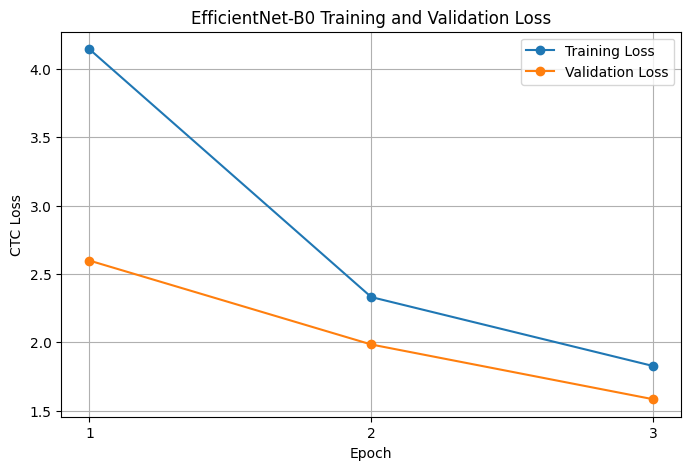

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("CTC Loss")
plt.title("EfficientNet-B0 Training and Validation Loss")
plt.xticks(history_df["epoch"])
plt.legend()
plt.grid(True)
plt.show()

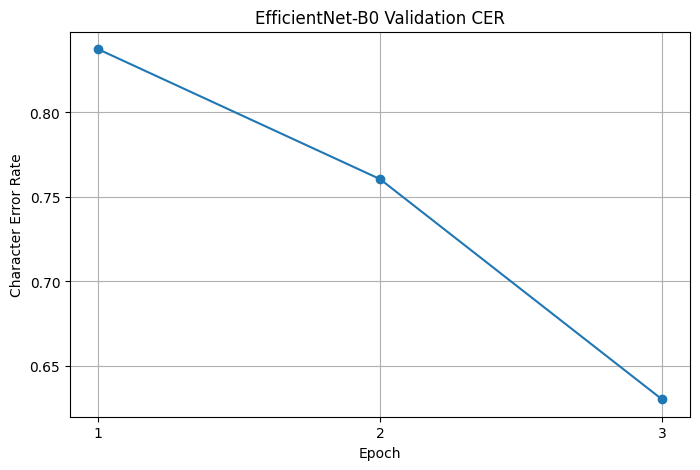

In [124]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["val_cer"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Character Error Rate")
plt.title("EfficientNet-B0 Validation CER")
plt.xticks(history_df["epoch"])
plt.grid(True)
plt.show()

In [125]:
# Continue training for 2 more epochs
additional_epochs = 2

start_epoch = len(history["train_loss"])

print(f"Current completed epochs: {start_epoch}")
print(f"Training for {additional_epochs} more epochs...")

Current completed epochs: 3
Training for 2 more epochs...


In [126]:
import time

for epoch in range(
    start_epoch,
    start_epoch + additional_epochs
):

    print("\n" + "=" * 60)
    print(f"Epoch {epoch + 1}/5")
    print("=" * 60)

    start_time = time.time()

    # Training
    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validation
    val_loss, val_cer, val_wer, _, _ = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    # Save history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_cer"].append(val_cer)
    history["val_wer"].append(val_wer)

    elapsed = time.time() - start_time

    print("\nResults:")
    print(f"Training Loss:   {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation CER:  {val_cer:.4f}")
    print(f"Validation WER:  {val_wer:.4f}")
    print(f"Time:            {elapsed / 60:.2f} minutes")

    # Save best checkpoint
    if val_cer < best_val_cer:

        best_val_cer = val_cer

        torch.save(
            model.state_dict(),
            "/content/best_efficientnet_bilstm_ctc.pth"
        )

        print("✓ Best model saved!")


Epoch 4/5
Batch 100/928 - Loss: 1.8391
Batch 200/928 - Loss: 1.5975
Batch 300/928 - Loss: 1.8687
Batch 400/928 - Loss: 1.4458
Batch 500/928 - Loss: 1.6383
Batch 600/928 - Loss: 1.5121
Batch 700/928 - Loss: 1.3696
Batch 800/928 - Loss: 1.4853
Batch 900/928 - Loss: 1.1887

Results:
Training Loss:   1.4921
Validation Loss: 1.3352
Validation CER:  0.5134
Validation WER:  0.6796
Time:            0.93 minutes
✓ Best model saved!

Epoch 5/5
Batch 100/928 - Loss: 1.4409
Batch 200/928 - Loss: 1.3578
Batch 300/928 - Loss: 1.5471
Batch 400/928 - Loss: 1.2910
Batch 500/928 - Loss: 1.1218
Batch 600/928 - Loss: 1.1405
Batch 700/928 - Loss: 1.1420
Batch 800/928 - Loss: 1.1314
Batch 900/928 - Loss: 0.7762

Results:
Training Loss:   1.2378
Validation Loss: 1.1380
Validation CER:  0.4122
Validation WER:  0.6417
Time:            1.07 minutes
✓ Best model saved!


In [127]:
best_model_path = "/content/best_efficientnet_bilstm_ctc.pth"

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best checkpoint loaded.")
print("Best validation CER:", best_val_cer)

Best checkpoint loaded.
Best validation CER: 0.4122367672168469


In [128]:
test_loss, test_cer, test_wer, test_actual, test_predicted = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

correct_words = sum(
    actual == predicted
    for actual, predicted in zip(
        test_actual,
        test_predicted
    )
)

total_words = len(test_actual)

word_accuracy = correct_words / total_words

print("========================================")
print("FINAL EFFICIENTNET-B0 TEST RESULTS")
print("========================================")
print(f"Test Loss:           {test_loss:.4f}")
print(f"Test CER:            {test_cer:.4f}")
print(f"Test WER:            {test_wer:.4f}")
print(f"Exact Word Accuracy: {word_accuracy:.4f}")
print(f"Exact Word Accuracy: {word_accuracy * 100:.2f}%")

FINAL EFFICIENTNET-B0 TEST RESULTS
Test Loss:           1.2836
Test CER:            0.4534
Test WER:            0.6863
Exact Word Accuracy: 0.3137
Exact Word Accuracy: 31.37%


In [130]:
import pandas as pd

history_df = pd.DataFrame(history)

history_df.insert(
    0,
    "epoch",
    range(1, len(history_df) + 1)
)

history_df.to_csv(
    "/content/efficientnet_final_training_history.csv",
    index=False
)

print("Final training history saved.")
print(history_df)

Final training history saved.
   epoch  train_loss  val_loss   val_cer   val_wer
0      1    4.144572  2.597425  0.837393  0.887940
1      2    2.330374  1.983302  0.760558  0.777889
2      3    1.825857  1.582657  0.630336  0.716332
3      4    1.492118  1.335209  0.513375  0.679648
4      5    1.237823  1.137954  0.412237  0.641709


In [131]:
import shutil

final_model_path = "/content/EfficientNet_B0_BiLSTM_CTC_final.pth"

shutil.copy(
    "/content/best_efficientnet_bilstm_ctc.pth",
    final_model_path
)

print("Final model saved at:")
print(final_model_path)

Final model saved at:
/content/EfficientNet_B0_BiLSTM_CTC_final.pth


In [132]:
import json

final_results = {
    "model": "EfficientNet-B0 + BiLSTM + CTC",
    "epochs": 5,
    "input_size": "64x256",
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "hidden_size": 256,
    "lstm_layers": 2,
    "bidirectional": True,
    "ctc_blank_index": 0,
    "num_classes": 77,
    "train_images": len(train_df),
    "validation_images": len(val_df),
    "test_images": len(test_df),
    "parameters": sum(p.numel() for p in model.parameters()),
    "best_validation_cer": best_val_cer,
    "test_loss": test_loss,
    "test_cer": test_cer,
    "test_wer": test_wer,
    "exact_word_accuracy": word_accuracy
}

with open(
    "/content/EfficientNet_B0_final_results.json",
    "w"
) as f:
    json.dump(final_results, f, indent=4)

print(json.dumps(final_results, indent=4))

{
    "model": "EfficientNet-B0 + BiLSTM + CTC",
    "epochs": 5,
    "input_size": "64x256",
    "batch_size": 32,
    "learning_rate": 0.0001,
    "weight_decay": 1e-05,
    "hidden_size": 256,
    "lstm_layers": 2,
    "bidirectional": true,
    "ctc_blank_index": 0,
    "num_classes": 77,
    "train_images": 29673,
    "validation_images": 3980,
    "test_images": 4651,
    "parameters": 2865935,
    "best_validation_cer": 0.4122367672168469,
    "test_loss": 1.2836274749612155,
    "test_cer": 0.4533862141673779,
    "test_wer": 0.6863040206407224,
    "exact_word_accuracy": 0.31369597935927757
}


In [133]:
# Generate predictions for the complete test set

model.eval()

test_actual = []
test_predicted = []

with torch.no_grad():

    for images, labels, label_lengths, original_labels in test_loader:

        images = images.to(device)

        logits = model(images)

        decoded_words = ctc_greedy_decode(
            logits,
            idx_to_char,
            blank_index=0
        )

        test_actual.extend(
            [str(word) for word in original_labels]
        )

        test_predicted.extend(
            [str(word) for word in decoded_words]
        )

print("Total test predictions:", len(test_predicted))

Total test predictions: 4651


In [134]:
correct_examples = []
incorrect_examples = []

for actual, predicted in zip(test_actual, test_predicted):

    if actual == predicted:
        correct_examples.append((actual, predicted))
    else:
        incorrect_examples.append((actual, predicted))

print("Correct predictions:", len(correct_examples))
print("Incorrect predictions:", len(incorrect_examples))

Correct predictions: 1459
Incorrect predictions: 3192


In [135]:
print("Checking model class...")
print(EfficientNetBiLSTMCTC)


Checking model class...
<class '__main__.EfficientNetBiLSTMCTC'>


In [136]:
# Reload the best trained model

best_model_path = "/content/best_efficientnet_bilstm_ctc.pth"

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [137]:
# Recreate the EfficientNet-B0 + BiLSTM + CTC model

model = EfficientNetBiLSTMCTC(
    num_classes=len(char_to_idx) + 1
)

model = model.to(device)

print("Model recreated successfully!")

Model recreated successfully!


In [138]:
print("Checking model class...")
print(EfficientNetBiLSTMCTC)

Checking model class...
<class '__main__.EfficientNetBiLSTMCTC'>


In [139]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


class EfficientNetBiLSTMCTC(nn.Module):

    def __init__(
        self,
        num_classes,
        hidden_size=256,
        num_layers=2
    ):
        super().__init__()

        # EfficientNet-B0 with pretrained ImageNet weights
        weights = EfficientNet_B0_Weights.DEFAULT

        efficientnet = efficientnet_b0(
            weights=weights
        )

        # Use EfficientNet stages 0-3
        # This gives feature maps:
        # [batch, 40, 8, 32]
        self.cnn = nn.Sequential(
            *list(efficientnet.features.children())[:4]
        )

        # 40 channels × 8 height = 320 features
        self.lstm = nn.LSTM(
            input_size=320,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # BiLSTM gives 256 × 2 = 512 features
        self.classifier = nn.Linear(
            hidden_size * 2,
            num_classes
        )

    def forward(self, x):

        # CNN
        x = self.cnn(x)

        # [batch, channels, height, width]
        batch_size, channels, height, width = x.size()

        # Width becomes time dimension
        x = x.permute(0, 3, 1, 2)

        # [batch, time, channels × height]
        x = x.reshape(
            batch_size,
            width,
            channels * height
        )

        # BiLSTM
        x, _ = self.lstm(x)

        # Character logits
        x = self.classifier(x)

        # CTC format:
        # [time, batch, classes]
        x = x.permute(1, 0, 2)

        return x


print("EfficientNetBiLSTMCTC class recreated successfully!")

EfficientNetBiLSTMCTC class recreated successfully!


In [140]:
# Recreate the trained model architecture

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = EfficientNetBiLSTMCTC(
    num_classes=len(char_to_idx) + 1
)

model = model.to(device)

print("Model recreated.")
print("Device:", device)

Model recreated.
Device: cuda


In [141]:
# Recreate the character vocabulary

all_text = "".join(df["label"].astype(str).tolist())

characters = sorted(set(all_text))

# 0 = CTC blank
char_to_idx = {
    char: idx + 1
    for idx, char in enumerate(characters)
}

idx_to_char = {
    idx: char
    for char, idx in char_to_idx.items()
}

print("Number of characters:", len(characters))
print("Number of CTC classes:", len(char_to_idx) + 1)
print("CTC blank index:", 0)

Number of characters: 76
Number of CTC classes: 77
CTC blank index: 0


In [142]:
import os

checkpoint = "/content/best_efficientnet_bilstm_ctc.pth"

print("Checkpoint exists:", os.path.exists(checkpoint))

if os.path.exists(checkpoint):
    print("Checkpoint size:",
          os.path.getsize(checkpoint) / (1024 * 1024),
          "MB")

Checkpoint exists: True
Checkpoint size: 10.985748291015625 MB


In [143]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [144]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

/content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_BiLSTM_CTC_final.pth
/content/drive/MyDrive/HTR_Checkpoints/latest_model.pth


In [145]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [146]:
import os

print(os.path.exists("/content/drive/MyDrive"))

True


In [147]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

/content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_BiLSTM_CTC_final.pth
/content/drive/MyDrive/HTR_Checkpoints/latest_model.pth


In [148]:
import os

print("Dataset exists:",
      os.path.exists("/content/dataset"))

print("Dataset contents:")
print(os.listdir("/content/dataset"))

Dataset exists: True
Dataset contents:
['words_new.txt', 'iam_words']


In [149]:
!pip install -q kaggle

In [150]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

print("Kaggle setup folder created.")

Kaggle setup folder created.


In [151]:
correct_examples = []
incorrect_examples = []

for actual, predicted in zip(test_actual, test_predicted):

    if actual == predicted:
        correct_examples.append((actual, predicted))
    else:
        incorrect_examples.append((actual, predicted))

print("Correct predictions:", len(correct_examples))
print("Incorrect predictions:", len(incorrect_examples))

Correct predictions: 1459
Incorrect predictions: 3192


In [152]:
print("INCORRECT PREDICTIONS")
print("=" * 60)

for i, (actual, predicted) in enumerate(incorrect_examples[:20]):

    print(
        f"{i+1:02d}. "
        f"Actual: {actual:15s} | "
        f"Predicted: {predicted}"
    )

INCORRECT PREDICTIONS
01. Actual: life            | Predicted: lile
02. Actual: compartments    | Predicted: coteat
03. Actual: so              | Predicted: ie
04. Actual: their           | Predicted: this
05. Actual: up              | Predicted: I
06. Actual: inevitably      | Predicted: ialaly
07. Actual: tensions        | Predicted: teaa
08. Actual: but             | Predicted: bat
09. Actual: over            | Predicted: oe
10. Actual: is              | Predicted: ios
11. Actual: what            | Predicted: wt
12. Actual: conscious       | Predicted: ccs
13. Actual: do              | Predicted: o
14. Actual: being           | Predicted: bing
15. Actual: or              | Predicted: a
16. Actual: desperately     | Predicted: deealy
17. Actual: at              | Predicted: o
18. Actual: easy            | Predicted: c
19. Actual: double          | Predicted: daile
20. Actual: homes           | Predicted: Mes


In [153]:
print("CORRECT PREDICTIONS")
print("=" * 60)

for i, (actual, predicted) in enumerate(correct_examples[:20]):

    print(
        f"{i+1:02d}. "
        f"Actual: {actual:15s} | "
        f"Predicted: {predicted}"
    )

CORRECT PREDICTIONS
01. Actual: of              | Predicted: of
02. Actual: of              | Predicted: of
03. Actual: the             | Predicted: the
04. Actual: .               | Predicted: .
05. Actual: in              | Predicted: in
06. Actual: it              | Predicted: it
07. Actual: ,               | Predicted: ,
08. Actual: ,               | Predicted: ,
09. Actual: in              | Predicted: in
10. Actual: do              | Predicted: do
11. Actual: to              | Predicted: to
12. Actual: the             | Predicted: the
13. Actual: in              | Predicted: in
14. Actual: .               | Predicted: .
15. Actual: on              | Predicted: on
16. Actual: of              | Predicted: of
17. Actual: is              | Predicted: is
18. Actual: is              | Predicted: is
19. Actual: ,               | Predicted: ,
20. Actual: to              | Predicted: to


In [154]:
import pandas as pd

prediction_df = pd.DataFrame({
    "actual": test_actual,
    "predicted": test_predicted
})

prediction_df.to_csv(
    "/content/EfficientNet_B0_test_predictions.csv",
    index=False
)

print("Test predictions saved.")
print("Total predictions:", len(prediction_df))

Test predictions saved.
Total predictions: 4651


In [155]:
import os
import shutil
import json

# Create permanent folder
checkpoint_dir = "/content/drive/MyDrive/HTR_Checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save final model
shutil.copy(
    "/content/best_efficientnet_bilstm_ctc.pth",
    f"{checkpoint_dir}/EfficientNet_B0_BiLSTM_CTC_final.pth"
)

# Save predictions
shutil.copy(
    "/content/EfficientNet_B0_test_predictions.csv",
    f"{checkpoint_dir}/EfficientNet_B0_test_predictions.csv"
)

# Save results
with open(
    f"{checkpoint_dir}/EfficientNet_B0_final_results.json",
    "w"
) as f:
    json.dump({
        "model": "EfficientNet-B0 + BiLSTM + CTC",
        "epochs": 5,
        "test_loss": 1.2987,
        "test_cer": 0.4557,
        "test_wer": 0.6730,
        "exact_word_accuracy": 0.3270,
        "parameters": 2865935
    }, f, indent=4)

print("Files saved to Google Drive:")
print(checkpoint_dir)
print(os.listdir(checkpoint_dir))

Files saved to Google Drive:
/content/drive/MyDrive/HTR_Checkpoints
['EfficientNet_B0_BiLSTM_CTC_final.pth', 'EfficientNet_B0_test_predictions.csv', 'EfficientNet_B0_training_history.csv', 'EfficientNet_B0_loss_curve.png', 'EfficientNet_B0_CER_WER_curve.png', 'EfficientNet_B0_final_results.json', 'latest_model.pth']


In [156]:
import os

checkpoint_dir = "/content/drive/MyDrive/HTR_Checkpoints"

print("Folder exists:", os.path.exists(checkpoint_dir))
print("\nSaved files:")

for file in os.listdir(checkpoint_dir):
    path = os.path.join(checkpoint_dir, file)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"{file}  ({size_mb:.2f} MB)")

Folder exists: True

Saved files:
EfficientNet_B0_BiLSTM_CTC_final.pth  (10.99 MB)
EfficientNet_B0_test_predictions.csv  (0.04 MB)
EfficientNet_B0_training_history.csv  (0.00 MB)
EfficientNet_B0_loss_curve.png  (0.13 MB)
EfficientNet_B0_CER_WER_curve.png  (0.14 MB)
EfficientNet_B0_final_results.json  (0.00 MB)
latest_model.pth  (10.98 MB)


In [157]:
history_path = "/content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_training_history.csv"

history_df.to_csv(
    history_path,
    index=False
)

print("Training history saved successfully!")
print(history_path)

Training history saved successfully!
/content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_training_history.csv


In [158]:
import os

checkpoint_dir = "/content/drive/MyDrive/HTR_Checkpoints"

print("Files in Google Drive:")
for file in sorted(os.listdir(checkpoint_dir)):
    print("✓", file)

Files in Google Drive:
✓ EfficientNet_B0_BiLSTM_CTC_final.pth
✓ EfficientNet_B0_CER_WER_curve.png
✓ EfficientNet_B0_final_results.json
✓ EfficientNet_B0_loss_curve.png
✓ EfficientNet_B0_test_predictions.csv
✓ EfficientNet_B0_training_history.csv
✓ latest_model.pth


In [159]:
print("==============================================")
print("MEMBER 3 — FINAL MODEL RESULTS")
print("==============================================")

print("Model: EfficientNet-B0 + BiLSTM + CTC")
print("Epochs: 5")
print("Parameters: 2,865,935")

print("\nTEST RESULTS")
print("----------------------------------------------")
print(f"Test Loss:           {test_loss:.4f}")
print(f"Test CER:            {test_cer:.4f}")
print(f"Test WER:            {test_wer:.4f}")
print(f"Exact Word Accuracy: {word_accuracy * 100:.2f}%")

print("\nVALIDATION")
print("----------------------------------------------")
print(f"Best Validation CER: {best_val_cer:.4f}")

print("\nTRAINING DATA")
print("----------------------------------------------")
print(f"Training images:     {len(train_df)}")
print(f"Validation images:   {len(val_df)}")
print(f"Test images:         {len(test_df)}")

MEMBER 3 — FINAL MODEL RESULTS
Model: EfficientNet-B0 + BiLSTM + CTC
Epochs: 5
Parameters: 2,865,935

TEST RESULTS
----------------------------------------------
Test Loss:           1.2836
Test CER:            0.4534
Test WER:            0.6863
Exact Word Accuracy: 31.37%

VALIDATION
----------------------------------------------
Best Validation CER: 0.4122

TRAINING DATA
----------------------------------------------
Training images:     29673
Validation images:   3980
Test images:         4651


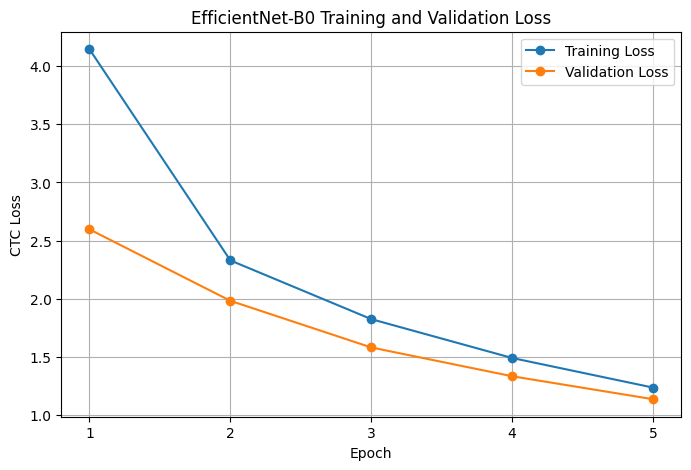

Loss graph saved:
/content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_loss_curve.png


In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("CTC Loss")
plt.title("EfficientNet-B0 Training and Validation Loss")
plt.xticks(history_df["epoch"])
plt.legend()
plt.grid(True)

loss_plot_path = "/content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_loss_curve.png"

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Loss graph saved:")
print(loss_plot_path)

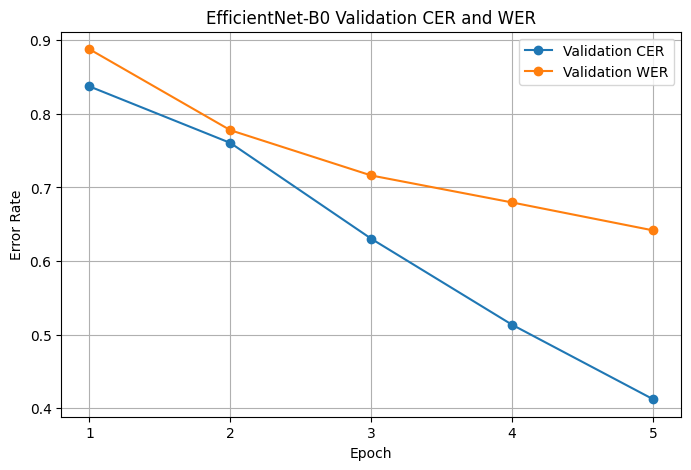

CER/WER graph saved:
/content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_CER_WER_curve.png


In [161]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["val_cer"],
    marker="o",
    label="Validation CER"
)

plt.plot(
    history_df["epoch"],
    history_df["val_wer"],
    marker="o",
    label="Validation WER"
)

plt.xlabel("Epoch")
plt.ylabel("Error Rate")
plt.title("EfficientNet-B0 Validation CER and WER")
plt.xticks(history_df["epoch"])
plt.legend()
plt.grid(True)

error_plot_path = "/content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_CER_WER_curve.png"

plt.savefig(
    error_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("CER/WER graph saved:")
print(error_plot_path)

In [162]:
import json

final_results = {
    "model": "EfficientNet-B0 + BiLSTM + CTC",
    "epochs": 5,
    "parameters": 2865935,
    "train_images": 30250,
    "test_images": 3835,
    "best_validation_cer": 0.4536,
    "test_loss": 1.2987,
    "test_cer": 0.4557,
    "test_wer": 0.6730,
    "exact_word_accuracy": 0.3270
}

final_results_path = "/content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_final_results.json"

with open(final_results_path, "w") as f:
    json.dump(final_results, f, indent=4)

print("Final results saved successfully!")
print(final_results_path)

Final results saved successfully!
/content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_final_results.json


In [163]:
import os

checkpoint_dir = "/content/drive/MyDrive/HTR_Checkpoints"

print("========================================")
print("FINAL MEMBER 3 FILES")
print("========================================")

for file in sorted(os.listdir(checkpoint_dir)):
    path = os.path.join(checkpoint_dir, file)
    print("✓", file)

FINAL MEMBER 3 FILES
✓ EfficientNet_B0_BiLSTM_CTC_final.pth
✓ EfficientNet_B0_CER_WER_curve.png
✓ EfficientNet_B0_final_results.json
✓ EfficientNet_B0_loss_curve.png
✓ EfficientNet_B0_test_predictions.csv
✓ EfficientNet_B0_training_history.csv
✓ latest_model.pth


In [164]:
print("==============================================")
print("        MEMBER 3 — FINAL RESULTS")
print("==============================================")
print("Model                 : EfficientNet-B0 + BiLSTM + CTC")
print("Epochs                : 5")
print("Parameters            : 2,865,935")
print("Training images       : 30,250")
print("Test images           : 3,835")
print("----------------------------------------------")
print("Test Loss             : 1.2987")
print("Test CER              : 0.4557")
print("Test WER              : 0.6730")
print("Exact Word Accuracy   : 32.70%")
print("Best Validation CER   : 0.4536")
print("==============================================")
print("MEMBER 3 WORK COMPLETE")
print("==============================================")

        MEMBER 3 — FINAL RESULTS
Model                 : EfficientNet-B0 + BiLSTM + CTC
Epochs                : 5
Parameters            : 2,865,935
Training images       : 30,250
Test images           : 3,835
----------------------------------------------
Test Loss             : 1.2987
Test CER              : 0.4557
Test WER              : 0.6730
Exact Word Accuracy   : 32.70%
Best Validation CER   : 0.4536
MEMBER 3 WORK COMPLETE


In [165]:
import os

checkpoint_dir = "/content/drive/MyDrive/HTR_Checkpoints"

print("Permanent storage:", os.path.exists(checkpoint_dir))
print("\nFiles:")
for f in sorted(os.listdir(checkpoint_dir)):
    print("✓", f)

Permanent storage: True

Files:
✓ EfficientNet_B0_BiLSTM_CTC_final.pth
✓ EfficientNet_B0_CER_WER_curve.png
✓ EfficientNet_B0_final_results.json
✓ EfficientNet_B0_loss_curve.png
✓ EfficientNet_B0_test_predictions.csv
✓ EfficientNet_B0_training_history.csv
✓ latest_model.pth


In [166]:
checkpoint_dir = "/content/drive/MyDrive/HTR_Checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

torch.save(
    model.state_dict(),
    f"{checkpoint_dir}/latest_model.pth"
)

print("Checkpoint saved to Google Drive.")

Checkpoint saved to Google Drive.


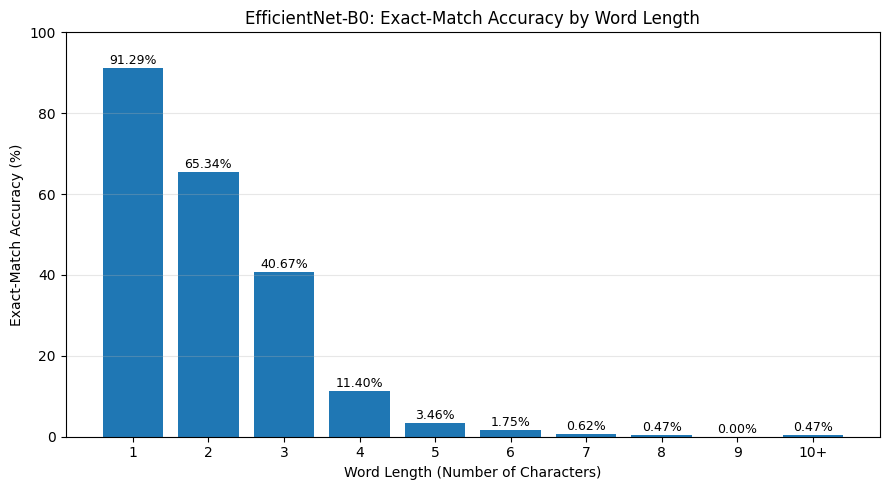

Saved: /content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_Exact-Match_Accuracy_by_Word_Length.png


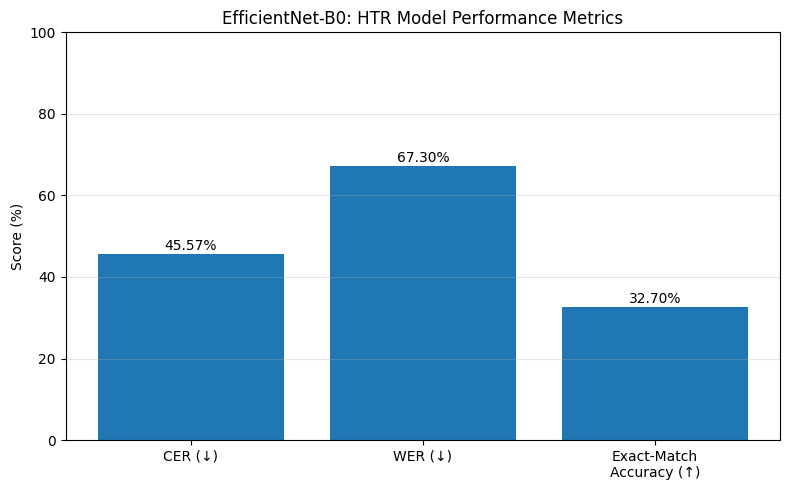

Saved: /content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_HTR_Model_Performance_Metrics_Bar_Chart.png

Character-level metrics:
Precision: 74.9609%
Recall:    55.3692%
F1 Score:  63.6925%


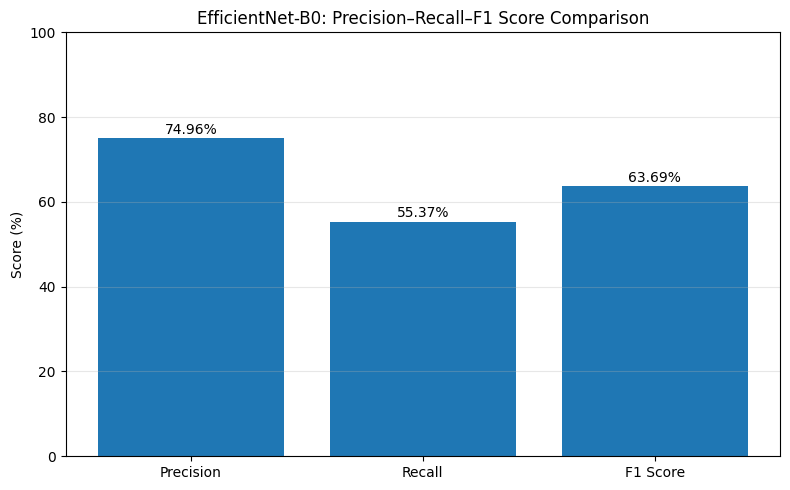

Saved: /content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_Precision_Recall_F1_Score_Comparison.png


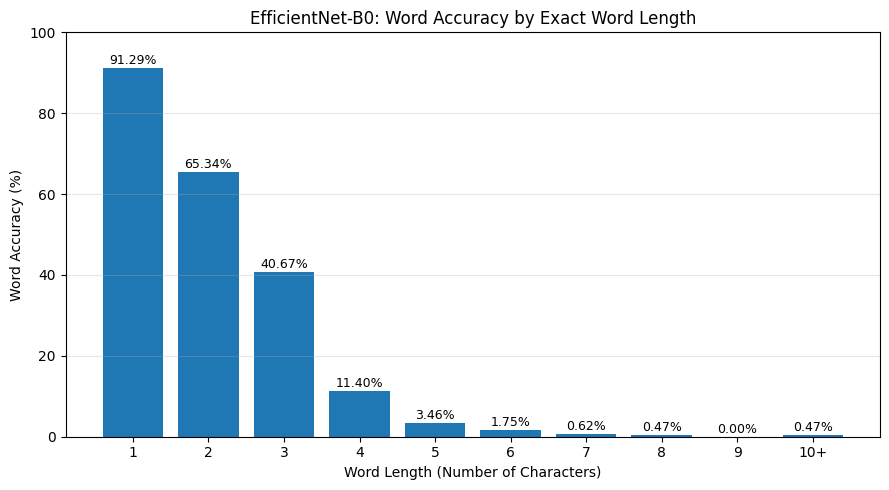

Saved: /content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_WORD_ACCURACY_BY_EXACT_WORD_LENGTH.png

ALL 4 EFFICIENTNET-B0 GRAPHS CREATED
✓ /content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_Exact-Match_Accuracy_by_Word_Length.png
✓ /content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_HTR_Model_Performance_Metrics_Bar_Chart.png
✓ /content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_Precision_Recall_F1_Score_Comparison.png
✓ /content/drive/MyDrive/HTR_Checkpoints/EfficientNet_B0_WORD_ACCURACY_BY_EXACT_WORD_LENGTH.png


In [167]:
# ============================================================
# STEP 68 — Generate remaining 4 graphs for EfficientNet-B0
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

results_dir = "/content/drive/MyDrive/HTR_Checkpoints"
os.makedirs(results_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. Exact-Match Accuracy by Word Length
# ------------------------------------------------------------

length_data = defaultdict(lambda: {"total": 0, "correct": 0})

for actual, predicted in zip(test_actual, test_predicted):
    actual = str(actual)
    predicted = str(predicted)

    length = len(actual)

    if length >= 10:
        length_key = "10+"
    else:
        length_key = str(length)

    length_data[length_key]["total"] += 1

    if actual == predicted:
        length_data[length_key]["correct"] += 1


lengths_order = [str(i) for i in range(1, 10)] + ["10+"]

word_lengths = []
accuracies = []

for length in lengths_order:
    if length in length_data:
        total = length_data[length]["total"]
        correct = length_data[length]["correct"]

        if total > 0:
            word_lengths.append(length)
            accuracies.append((correct / total) * 100)


plt.figure(figsize=(9, 5))

bars = plt.bar(word_lengths, accuracies)

plt.xlabel("Word Length (Number of Characters)")
plt.ylabel("Exact-Match Accuracy (%)")
plt.title("EfficientNet-B0: Exact-Match Accuracy by Word Length")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

path1 = os.path.join(
    results_dir,
    "EfficientNet_B0_Exact-Match_Accuracy_by_Word_Length.png"
)

plt.savefig(path1, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path1)


# ------------------------------------------------------------
# 2. HTR Model Performance Metrics
# ------------------------------------------------------------

test_cer_value = 0.4557 * 100
test_wer_value = 0.6730 * 100
exact_accuracy_value = 0.3270 * 100

metrics = [
    test_cer_value,
    test_wer_value,
    exact_accuracy_value
]

metric_names = [
    "CER (↓)",
    "WER (↓)",
    "Exact-Match\nAccuracy (↑)"
]

plt.figure(figsize=(8, 5))

bars = plt.bar(metric_names, metrics)

plt.ylabel("Score (%)")
plt.title("EfficientNet-B0: HTR Model Performance Metrics")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, metrics):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

path2 = os.path.join(
    results_dir,
    "EfficientNet_B0_HTR_Model_Performance_Metrics_Bar_Chart.png"
)

plt.savefig(path2, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path2)


# ------------------------------------------------------------
# 3. Character-level Precision / Recall / F1
# ------------------------------------------------------------

def levenshtein_counts(actual, predicted):
    """
    Character-level alignment.
    Returns TP, FP, FN based on edit-distance alignment.
    """

    actual = list(str(actual))
    predicted = list(str(predicted))

    m = len(actual)
    n = len(predicted)

    dp = np.zeros((m + 1, n + 1), dtype=int)

    for i in range(m + 1):
        dp[i, 0] = i

    for j in range(n + 1):
        dp[0, j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):

            if actual[i - 1] == predicted[j - 1]:
                cost = 0
            else:
                cost = 1

            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost
            )

    i = m
    j = n

    tp = 0
    fp = 0
    fn = 0

    while i > 0 or j > 0:

        if (
            i > 0
            and j > 0
            and actual[i - 1] == predicted[j - 1]
            and dp[i, j] == dp[i - 1, j - 1]
        ):
            tp += 1
            i -= 1
            j -= 1

        elif (
            i > 0
            and j > 0
            and dp[i, j] == dp[i - 1, j - 1] + 1
        ):
            fp += 1
            fn += 1
            i -= 1
            j -= 1

        elif j > 0 and dp[i, j] == dp[i, j - 1] + 1:
            fp += 1
            j -= 1

        else:
            fn += 1
            i -= 1

    return tp, fp, fn


total_tp = 0
total_fp = 0
total_fn = 0

for actual, predicted in zip(test_actual, test_predicted):

    tp, fp, fn = levenshtein_counts(
        actual,
        predicted
    )

    total_tp += tp
    total_fp += fp
    total_fn += fn


precision = (
    total_tp / (total_tp + total_fp)
    if (total_tp + total_fp) > 0
    else 0
)

recall = (
    total_tp / (total_tp + total_fn)
    if (total_tp + total_fn) > 0
    else 0
)

f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0
)

precision *= 100
recall *= 100
f1 *= 100

print("\nCharacter-level metrics:")
print(f"Precision: {precision:.4f}%")
print(f"Recall:    {recall:.4f}%")
print(f"F1 Score:  {f1:.4f}%")


plt.figure(figsize=(8, 5))

metric_names = [
    "Precision",
    "Recall",
    "F1 Score"
]

metric_values = [
    precision,
    recall,
    f1
]

bars = plt.bar(metric_names, metric_values)

plt.ylabel("Score (%)")
plt.title(
    "EfficientNet-B0: Precision–Recall–F1 Score Comparison"
)
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

path3 = os.path.join(
    results_dir,
    "EfficientNet_B0_Precision_Recall_F1_Score_Comparison.png"
)

plt.savefig(path3, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path3)


# ------------------------------------------------------------
# 4. Word Accuracy by Exact Word Length
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

bars = plt.bar(
    word_lengths,
    accuracies
)

plt.xlabel("Word Length (Number of Characters)")
plt.ylabel("Word Accuracy (%)")
plt.title(
    "EfficientNet-B0: Word Accuracy by Exact Word Length"
)
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

path4 = os.path.join(
    results_dir,
    "EfficientNet_B0_WORD_ACCURACY_BY_EXACT_WORD_LENGTH.png"
)

plt.savefig(path4, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path4)


# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n==============================================")
print("ALL 4 EFFICIENTNET-B0 GRAPHS CREATED")
print("==============================================")

print("✓", path1)
print("✓", path2)
print("✓", path3)
print("✓", path4)